Mounted at /content/drive
Shape data: (613, 31)

===== FOLD 1 =====

Early stopping occurred at epoch 52 with best_epoch = 32 and best_val_0_auc = 0.80571
Accuracy : 0.7258064516129032
Precision: 0.47619047619047616
Recall   : 0.625
F1 Score : 0.5405405405405406
AUC      : 0.8057065217391304

===== FOLD 2 =====


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 77 with best_epoch = 57 and best_val_0_auc = 0.85734
Accuracy : 0.7903225806451613
Precision: 0.56
Recall   : 0.875
F1 Score : 0.6829268292682927
AUC      : 0.8573369565217391

===== FOLD 3 =====


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 40 with best_epoch = 20 and best_val_0_auc = 0.79216
Accuracy : 0.6935483870967742
Precision: 0.45454545454545453
Recall   : 0.5882352941176471
F1 Score : 0.5128205128205128
AUC      : 0.7921568627450981

===== FOLD 4 =====


...

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 45 with best_epoch = 25 and best_val_0_auc = 0.78333
Accuracy : 0.6885245901639344
Precision: 0.44
Recall   : 0.6875
F1 Score : 0.5365853658536586
AUC      : 0.7833333333333333

===== FOLD 10 =====


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 64 with best_epoch = 44 and best_val_0_auc = 0.82222
Accuracy : 0.7704918032786885
Precision: 0.5454545454545454
Recall   : 0.75
F1 Score : 0.631578947368421
AUC      : 0.8222222222222223

=========== HASIL CV (10 FOLD) ===========
Accuracy Mean : 0.7521152829190905
Precision Mean: 0.5198597130006426
Recall Mean   : 0.8025735294117646
F1 Mean       : 0.6287706139974935
AUC Mean      : 0.8331589229894856


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


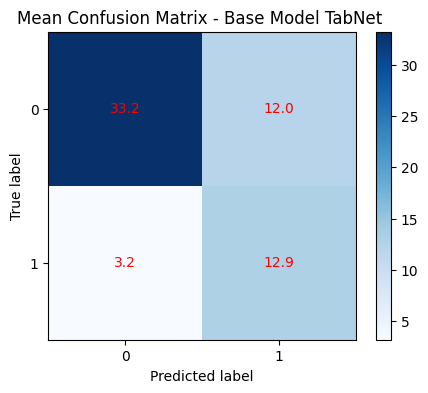

<Figure size 600x500 with 0 Axes>

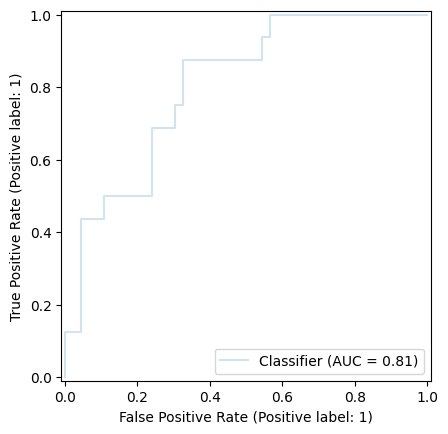

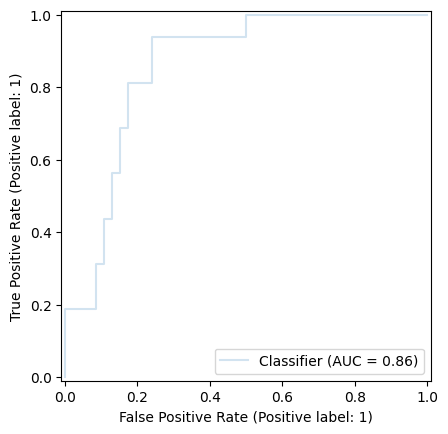

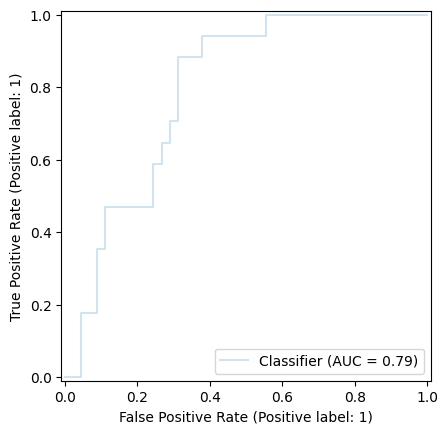

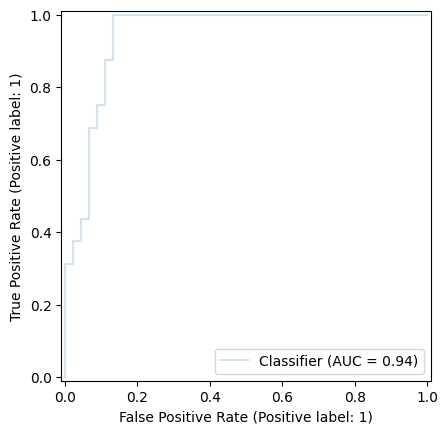

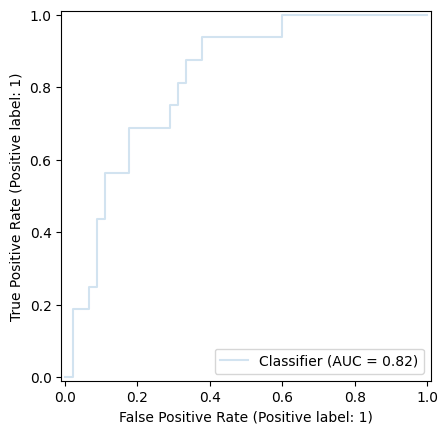

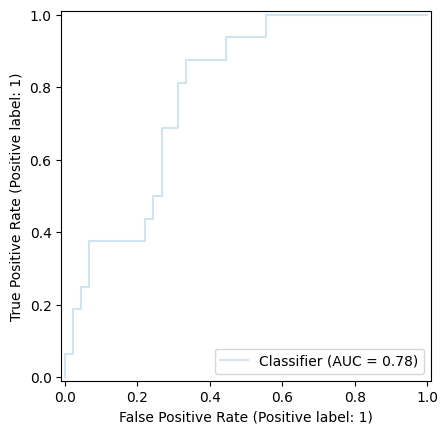

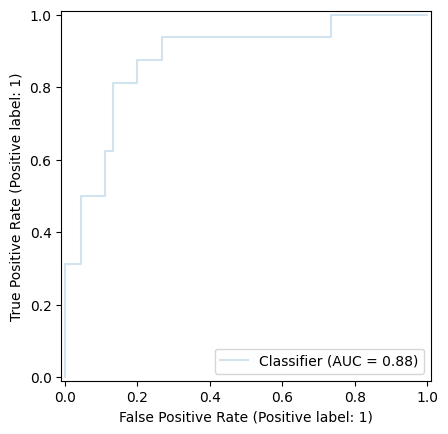

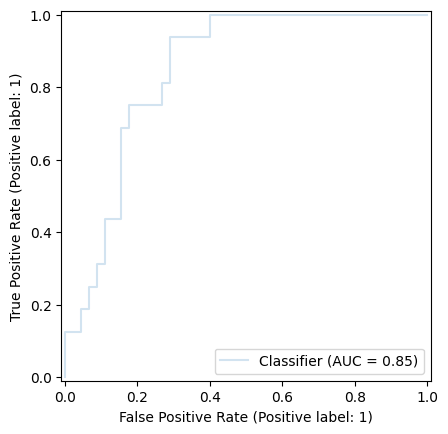

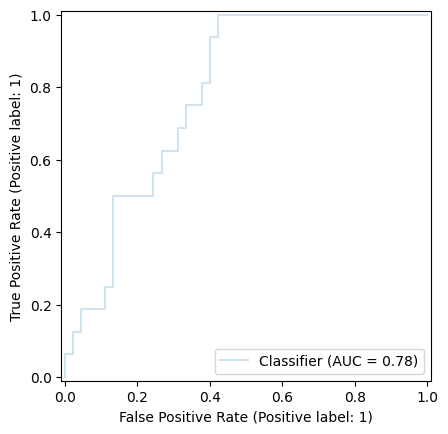

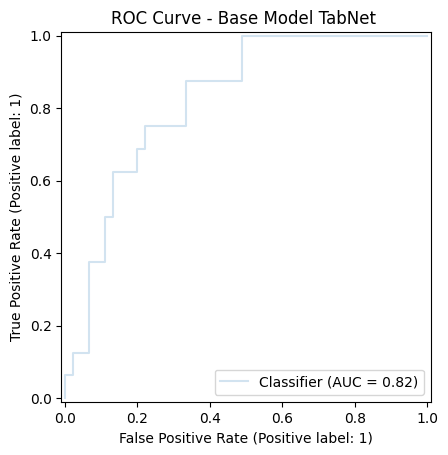

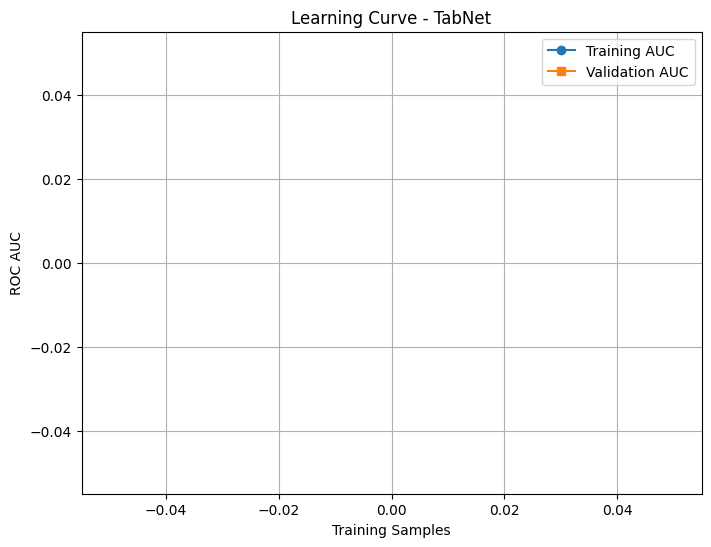

Successfully saved model at /content/drive/MyDrive/Tesis/Fix FE CV/TabNet/Base Model/tabnet_model.zip
Model, scaler, dan feature list berhasil disimpan.


In [2]:
!pip install pytorch-tabnet

# ======================================
# IMPORT
# ======================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, RocCurveDisplay,
    classification_report
)
from imblearn.over_sampling import SMOTE
from pytorch_tabnet.tab_model import TabNetClassifier

import torch
import os
import joblib

from google.colab import drive
drive.mount("/content/drive")

# ======================================
# LOAD DATASET
# ======================================
DATA_PATH = "/content/drive/MyDrive/Tesis/Eksperimen/Dataset/Data Gabungan/fix_data_gabungan_fe_tambahan_2.csv"
df = pd.read_csv(DATA_PATH)

print("Shape data:", df.shape)

# ======================================
# SPLIT FEATURES & TARGET
# ======================================
target_col = "Gallstone Status"
X = df.drop(columns=[target_col])
y = df[target_col]

# encode jika target berupa string
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)

# ======================================
# ONE-HOT ENCODING
# ======================================
X_encoded = pd.get_dummies(X)

# ======================================
# SCALING
# ======================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# ======================================
# K-FOLD CV (10 FOLD)
# ======================================
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

acc_list = []
prec_list = []
rec_list = []
f1_list = []
auc_list = []
cms = []
roc_curves = []

fold = 1
for train_idx, test_idx in kf.split(X_scaled, y):
    print(f"\n===== FOLD {fold} =====")

    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # ======================================
    # SMOTE (ONLY TRAIN SPLIT)
    # ======================================
    sm = SMOTE(random_state=42)
    X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

    # ======================================
    # TRAIN TABNET
    # ======================================
    clf = TabNetClassifier(
        n_d=32, n_a=32,
        n_steps=5,
        gamma=1.5,
        lambda_sparse=1e-4,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=1e-3),
        verbose=0,
        seed=42
    )

    clf.fit(
        X_train_sm, y_train_sm,
        eval_set=[(X_test, y_test)],
        eval_metric=["auc"],
        max_epochs=200,
        patience=20,
        batch_size=256,
        virtual_batch_size=128
    )

    # ======================================
    # PREDIKSI
    # ======================================
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    # ======================================
    # METRIK
    # ======================================
    acc_list.append(accuracy_score(y_test, y_pred))
    prec_list.append(precision_score(y_test, y_pred))
    rec_list.append(recall_score(y_test, y_pred))
    f1_list.append(f1_score(y_test, y_pred))
    auc_list.append(roc_auc_score(y_test, y_proba))

    cm = confusion_matrix(y_test, y_pred)
    cms.append(cm)

    roc_curves.append((y_test, y_proba))

    print("Accuracy :", acc_list[-1])
    print("Precision:", prec_list[-1])
    print("Recall   :", rec_list[-1])
    print("F1 Score :", f1_list[-1])
    print("AUC      :", auc_list[-1])

    fold += 1

# ======================================
# HASIL RATA-RATA CV
# ======================================
print("\n=========== HASIL CV (10 FOLD) ===========")
print("Accuracy Mean :", np.mean(acc_list))
print("Precision Mean:", np.mean(prec_list))
print("Recall Mean   :", np.mean(rec_list))
print("F1 Mean       :", np.mean(f1_list))
print("AUC Mean      :", np.mean(auc_list))

# ======================================
# CONFUSION MATRIX (RATA-RATA)
# ======================================
cm_mean = np.mean(cms, axis=0)
plt.figure(figsize=(5,4))
plt.imshow(cm_mean, cmap="Blues")
plt.title("Mean Confusion Matrix - Base Model TabNet ")
plt.colorbar()

for i in range(cm_mean.shape[0]):
    for j in range(cm_mean.shape[1]):
        plt.text(j, i, f"{cm_mean[i,j]:.1f}", ha='center', va='center', color="red")


plt.xticks([0,1], ["0","1"])
plt.yticks([0,1], ["0","1"])
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

# ======================================
# MEAN ROC CURVE
# ======================================
plt.figure(figsize=(6,5))
for y_test, y_proba in roc_curves:
    RocCurveDisplay.from_predictions(y_test, y_proba, alpha=0.2)

plt.title("ROC Curve - Base Model TabNet ")
plt.show()

# ======================================
# LEARNING CURVE
# ======================================
tabnet_lc = TabNetClassifier(
    n_d=32, n_a=32,
    n_steps=5,
    gamma=1.5,
    lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=1e-3),
    verbose=0,
    seed=42
)

train_sizes, train_scores, valid_scores = learning_curve(
    estimator=tabnet_lc,
    X=X_scaled,
    y=y,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
valid_mean = valid_scores.mean(axis=1)
valid_std = valid_scores.std(axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, label="Training AUC", marker="o")
plt.plot(train_sizes, valid_mean, label="Validation AUC", marker="s")

plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.2)
plt.fill_between(train_sizes, valid_mean-valid_std, valid_mean+valid_std, alpha=0.2)

plt.title("Learning Curve - TabNet")
plt.xlabel("Training Samples")
plt.ylabel("ROC AUC")
plt.grid()
plt.legend()
plt.show()

# ======================================
# SAVE MODEL + SCALER + FEATURES
# ======================================
output_dir = "/content/drive/MyDrive/Tesis/Fix FE CV/TabNet/Base Model/"
os.makedirs(output_dir, exist_ok=True)

# Simpan model terbaik (fold terakhir)
clf.save_model(output_dir + "tabnet_model")

joblib.dump(scaler, output_dir + "scaler.pkl")
joblib.dump(X_encoded.columns.tolist(), output_dir + "columns.pkl")

print("Model, scaler, dan feature list berhasil disimpan.")


In [3]:
# ======================================================
# INSTALL
# ======================================================
!pip install pytorch-tabnet imbalanced-learn

# ======================================================
# IMPORT
# ======================================================
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, learning_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline   # FIX DI SINI

from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.base import BaseEstimator, ClassifierMixin
import torch
import joblib


In [4]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
DATA_PATH = "/content/drive/MyDrive/Tesis/Eksperimen/Dataset/Data Gabungan/fix_data_gabungan_fe_tambahan_2.csv"
df = pd.read_csv(DATA_PATH)

target_col = "Gallstone Status"

print("Shape:", df.shape)
df.head()


Shape: (613, 31)


,Hypothyroidism,Creatinine,Diabetes Mellitus (DM),Alanin Aminotransferaz (ALT),Low Density Lipoprotein (LDL),Hemoglobin (HGB),Coronary Artery Disease (CAD),Total Body Fat Ratio (TBFR) (%),Total Body Water (TBW),Height,...,Aspartat Aminotransferaz (AST),Glomerular Filtration Rate (GFR),Glucose,TC/HDL Ratio,LDL/HDL Ratio,Atherogenic Index,Triglyceride/HDL Ratio,Non-Lean Mass (NLM),Body Fat/Water Ratio,De Ritis Ratio
0,0,1.36,1,83.0,6.5,37.8,0,25.213043,36.87740,160.0,...,13.6,54.218927,130.0,6.243386,0.343915,5.243386,15.555556,-5.786957,0.683699,0.163855
1,0,0.81,0,16.0,75.0,14.3,0,13.352632,34.10012,170.0,...,25.0,94.586269,100.0,2.000000,1.000000,1.000000,0.866667,-29.647368,0.391571,1.562500
2,0,0.81,0,15.0,78.0,14.5,0,20.100000,34.67564,160.0,...,20.0,99.353543,100.0,2.083333,1.083333,1.083333,0.944444,-19.900000,0.579658,1.333333
3,0,0.81,0,14.0,78.0,15.1,0,21.885714,39.11164,170.0,...,23.0,99.353543,100.0,2.000000,1.040000,1.000000,0.866667,-8.114286,0.559570,1.642857
4,0,0.72,0,14.0,80.0,12.3,0,29.500000,26.26800,150.0,...,25.0,93.612393,98.0,2.384615,1.230769,1.384615,1.076923,-20.500000,1.123039,1.785714


In [6]:
df = df.copy()

# Encode target
le = LabelEncoder()
df[target_col] = le.fit_transform(df[target_col])

X = df.drop(columns=[target_col])
y = df[target_col]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

feature_names = list(X.columns)


In [7]:
param_dist = {
    "n_d": [16, 32, 64],
    "n_a": [16, 32, 64],
    "n_steps": [3, 4, 5, 6],
    "gamma": [1.0, 1.2, 1.5, 2.0],
    "lr": [1e-2, 5e-3, 1e-3, 5e-4]
}


In [8]:
class TabNetSklearn(BaseEstimator, ClassifierMixin):
    def __init__(self, n_d=16, n_a=16, n_steps=3, gamma=1.0, lr=1e-3):
        self.n_d = n_d
        self.n_a = n_a
        self.n_steps = n_steps
        self.gamma = gamma
        self.lr = lr

    def fit(self, X, y):
        self.model = TabNetClassifier(
            n_d=self.n_d,
            n_a=self.n_a,
            n_steps=self.n_steps,
            gamma=self.gamma,
            optimizer_params={"lr": self.lr},
            verbose=0
        )

        self.model.fit(
            X_train=X, y_train=y,
            max_epochs=200,
            patience=20,
            batch_size=256,
            virtual_batch_size=128
        )
        return self

    def predict(self, X):
        return self.model.predict(X)

    def predict_proba(self, X):
        return self.model.predict_proba(X)


In [9]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf", TabNetSklearn())
])

param_grid = {f"clf__{k}": v for k, v in param_dist.items()}

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("Running Random Search...")
random_search.fit(X_scaled, y)

print("\nBest Score:", random_search.best_score_)
print("Best Params:", random_search.best_params_)


Running Random Search...
Fitting 10 folds for each of 20 candidates, totalling 200 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)



Best Score: nan
Best Params: {'clf__n_steps': 5, 'clf__n_d': 32, 'clf__n_a': 32, 'clf__lr': 0.001, 'clf__gamma': 1.2}


In [10]:
best_params = {k.replace("clf__", ""): v for k, v in random_search.best_params_.items()}

final_model = TabNetClassifier(
    n_d=best_params["n_d"],
    n_a=best_params["n_a"],
    n_steps=best_params["n_steps"],
    gamma=best_params["gamma"],
    optimizer_params={"lr": best_params["lr"]}
)

final_model.fit(
    X_train=X_scaled, y_train=y,
    max_epochs=200,
    patience=20,
    batch_size=256,
    virtual_batch_size=128
)


epoch 0  | loss: 0.98037 |  0:00:00s


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")
/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


epoch 1  | loss: 0.96704 |  0:00:00s
epoch 2  | loss: 0.93508 |  0:00:00s
epoch 3  | loss: 0.82013 |  0:00:00s
epoch 4  | loss: 0.99459 |  0:00:00s
epoch 5  | loss: 0.92073 |  0:00:00s
epoch 6  | loss: 0.92726 |  0:00:00s
epoch 7  | loss: 0.86049 |  0:00:01s
epoch 8  | loss: 0.93185 |  0:00:01s
epoch 9  | loss: 0.84528 |  0:00:01s
epoch 10 | loss: 0.85272 |  0:00:01s
epoch 11 | loss: 0.83217 |  0:00:01s
epoch 12 | loss: 0.85372 |  0:00:01s
epoch 13 | loss: 0.82009 |  0:00:01s
epoch 14 | loss: 0.7872  |  0:00:01s
epoch 15 | loss: 0.81077 |  0:00:01s
epoch 16 | loss: 0.81319 |  0:00:02s
epoch 17 | loss: 0.71563 |  0:00:02s
epoch 18 | loss: 0.72234 |  0:00:02s
epoch 19 | loss: 0.81287 |  0:00:02s
epoch 20 | loss: 0.7958  |  0:00:02s
epoch 21 | loss: 0.75628 |  0:00:02s
epoch 22 | loss: 0.70453 |  0:00:02s
epoch 23 | loss: 0.7268  |  0:00:03s
epoch 24 | loss: 0.72186 |  0:00:03s
epoch 25 | loss: 0.61648 |  0:00:03s
epoch 26 | loss: 0.73602 |  0:00:03s
epoch 27 | loss: 0.64799 |  0:00:03s
e

In [11]:
pred = final_model.predict(X_scaled)
proba = final_model.predict_proba(X_scaled)[:, 1]

print("\n=== METRIK EVALUASI ===")
print("Accuracy :", accuracy_score(y, pred))
print("Precision:", precision_score(y, pred))
print("Recall   :", recall_score(y, pred))
print("F1 Score :", f1_score(y, pred))
print("ROC-AUC  :", roc_auc_score(y, proba))

print("\n=== Classification Report ===")
print(classification_report(y, pred))



=== METRIK EVALUASI ===
Accuracy : 0.8515497553017944
Precision: 0.7611940298507462
Recall   : 0.6335403726708074
F1 Score : 0.6915254237288135
ROC-AUC  : 0.9219617435277303

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.88      0.93      0.90       452
           1       0.76      0.63      0.69       161

    accuracy                           0.85       613
   macro avg       0.82      0.78      0.80       613
weighted avg       0.85      0.85      0.85       613



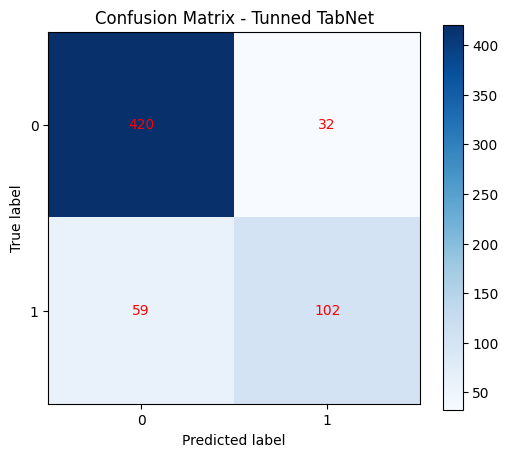

In [12]:
cm = confusion_matrix(y, pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - Tunned TabNet")
plt.colorbar()
plt.xticks([0,1], ["0","1"])
plt.yticks([0,1], ["0","1"])
plt.xlabel("Predicted label")
plt.ylabel("True label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha='center', va='center', color='red')

plt.show()


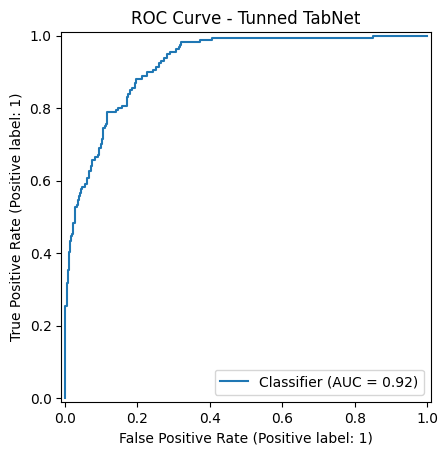

In [17]:
RocCurveDisplay.from_predictions(y, proba)
plt.title("ROC Curve - Tunned TabNet")
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
20 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/imblearn/pipeline.py", line 518, in fit
    Xt, yt = self._fit(X, y, routed_para

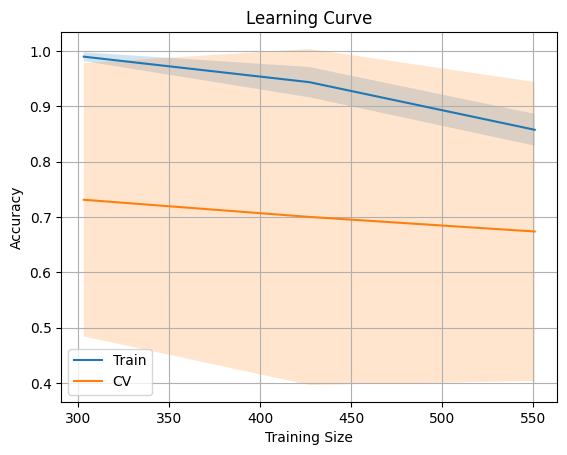

In [14]:
train_sizes, train_scores, test_scores = learning_curve(
    estimator=random_search.best_estimator_,
    X=X_scaled,
    y=y,
    cv=10,
    scoring="accuracy",
    n_jobs=-1
)

plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
plt.plot(train_sizes, test_scores.mean(axis=1), label="CV")

plt.fill_between(train_sizes,
                 train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1),
                 alpha=0.2)

plt.fill_between(train_sizes,
                 test_scores.mean(axis=1) - test_scores.std(axis=1),
                 test_scores.mean(axis=1) + test_scores.std(axis=1),
                 alpha=0.2)

plt.title("Learning Curve")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()


In [15]:
output_dir = "/content/drive/MyDrive/Tesis/Fix FE CV/TabNet/Tuned Model/"
os.makedirs(output_dir, exist_ok=True)

final_model.save_model(output_dir + "tabnet_model")

joblib.dump(scaler, output_dir + "scaler.pkl")
joblib.dump(feature_names, output_dir + "features.pkl")

with open(output_dir + "best_params.json", "w") as f:
    json.dump(best_params, f, indent=4)

print("Model, scaler, dan fitur berhasil disimpan.")


Successfully saved model at /content/drive/MyDrive/Tesis/Fix FE CV/TabNet/Tuned Model/tabnet_model.zip
Model, scaler, dan fitur berhasil disimpan.
